---
aliases:
- /PDS_Pytorch_reg
date: '2024-12-30'
title: PDS Pytorch Regression
description: I dont give a f
image: image.png
categories: [python, programming]
---

## SimpleLinear Regression

###  2.1 Problem 1

 1. Do anexploratory data analysis on the iris dataset from seaborn library.

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the iris dataset
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [88]:
iris.query('species != "setosa"').head()

,sepal_length,sepal_width,petal_length,petal_width,species,is_setosa
50,7.0,3.2,4.7,1.4,versicolor,0
51,6.4,3.2,4.5,1.5,versicolor,0
52,6.9,3.1,4.9,1.5,versicolor,0
53,5.5,2.3,4.0,1.3,versicolor,0
54,6.5,2.8,4.6,1.5,versicolor,0


In [7]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


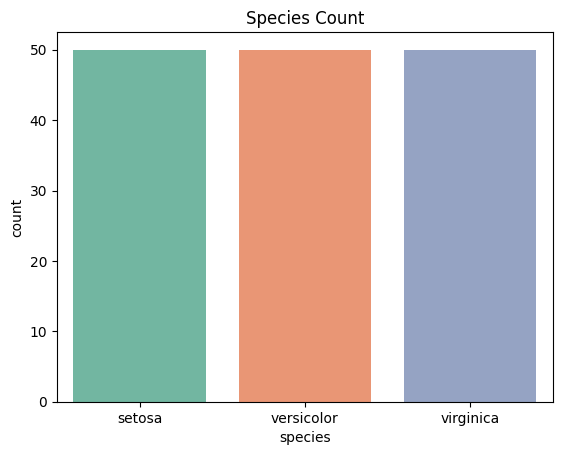

In [33]:
sns.countplot(x='species', data=iris, palette='Set2', hue='species')
plt.title('Species Count')
plt.show()

In [6]:
#Statistics of this dataset
stats = iris.describe()
stats

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


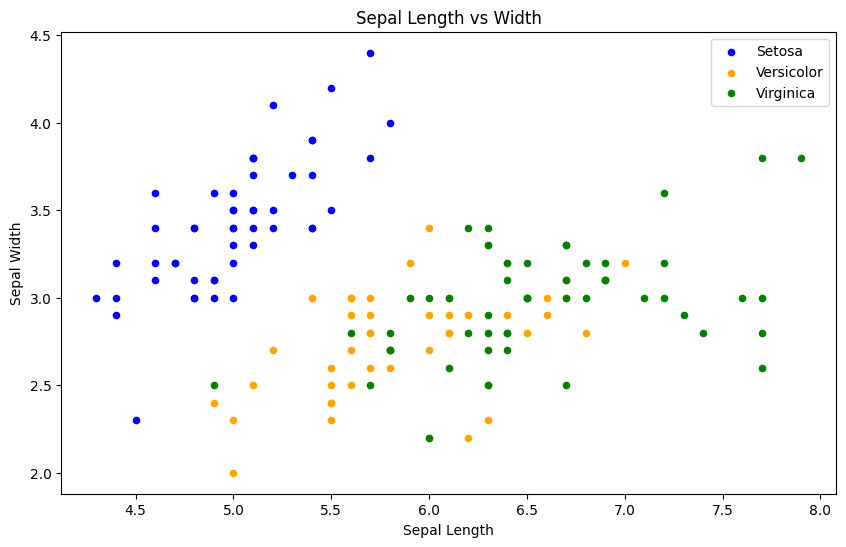

In [14]:
# Let's plot a scatter plot of the Iris features
fig = iris[iris.species=='setosa'].plot(kind='scatter', x='sepal_length', y='sepal_width', color='blue', label='Setosa', figsize=(10, 6))
iris[iris.species=='versicolor'].plot(kind='scatter', x='sepal_length', y='sepal_width', color='orange', label='Versicolor', ax=fig)
iris[iris.species=='virginica'].plot(kind='scatter', x='sepal_length', y='sepal_width', color='green', label='Virginica', ax=fig)
fig.set_xlabel("Sepal Length")
fig.set_ylabel("Sepal Width")
fig.set_title("Sepal Length vs Width")
plt.show()

Scatter Plots¶
Scatter plots use a collection of points placed using Cartesian coordinates to display values from two variables.

By displaying a variable in each axis, we can detect if a relationship or correlation between the two variables exists. Scatter Plots are also great for observing the spread of the data as they retain the exact data values and sample size.

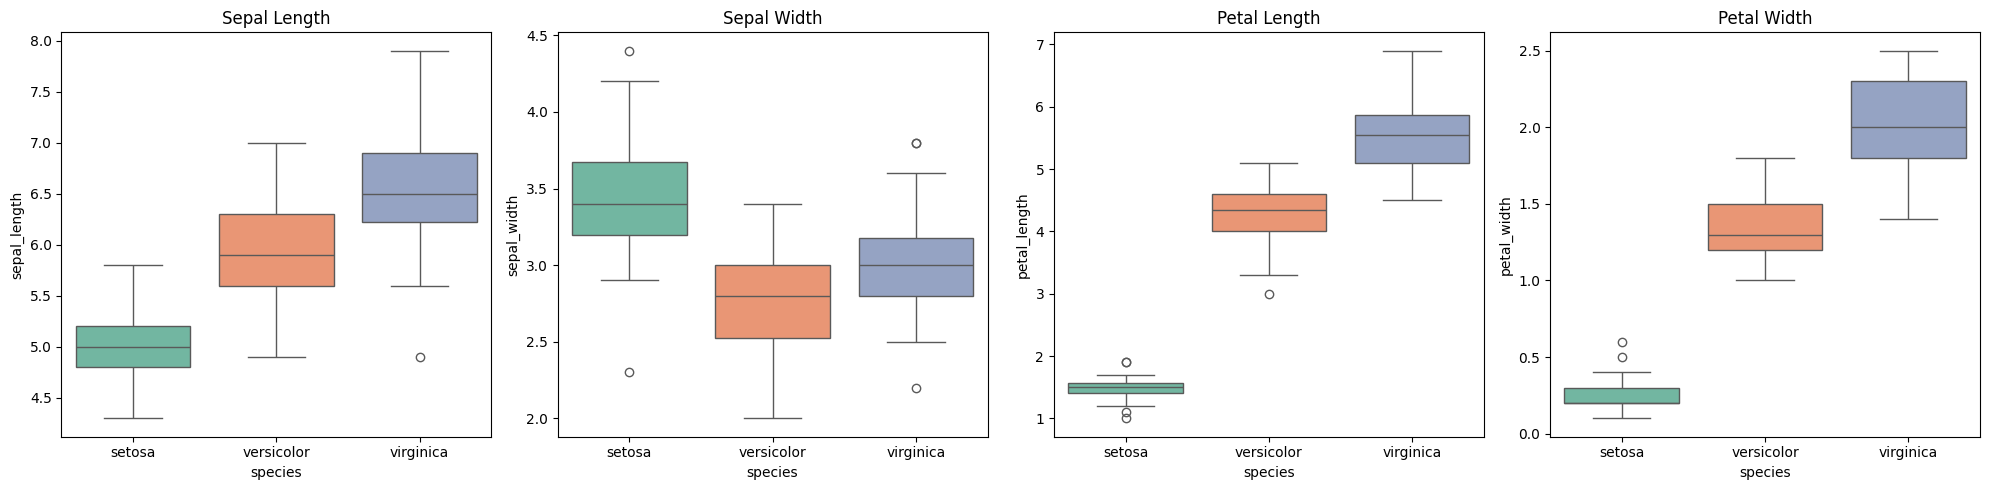

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sns.boxplot(x="species", y="sepal_length", data=iris, ax=axes[0], palette="Set2", hue="species")
axes[0].set_title('Sepal Length')

sns.boxplot(x="species", y="sepal_width", data=iris, ax=axes[1], palette="Set2", hue="species")
axes[1].set_title('Sepal Width')

sns.boxplot(x="species", y="petal_length", data=iris, ax=axes[2], palette="Set2", hue="species")
axes[2].set_title('Petal Length')

sns.boxplot(x="species", y="petal_width", data=iris, ax=axes[3], palette="Set2", hue="species")
axes[3].set_title('Petal Width')

plt.tight_layout()
plt.show()

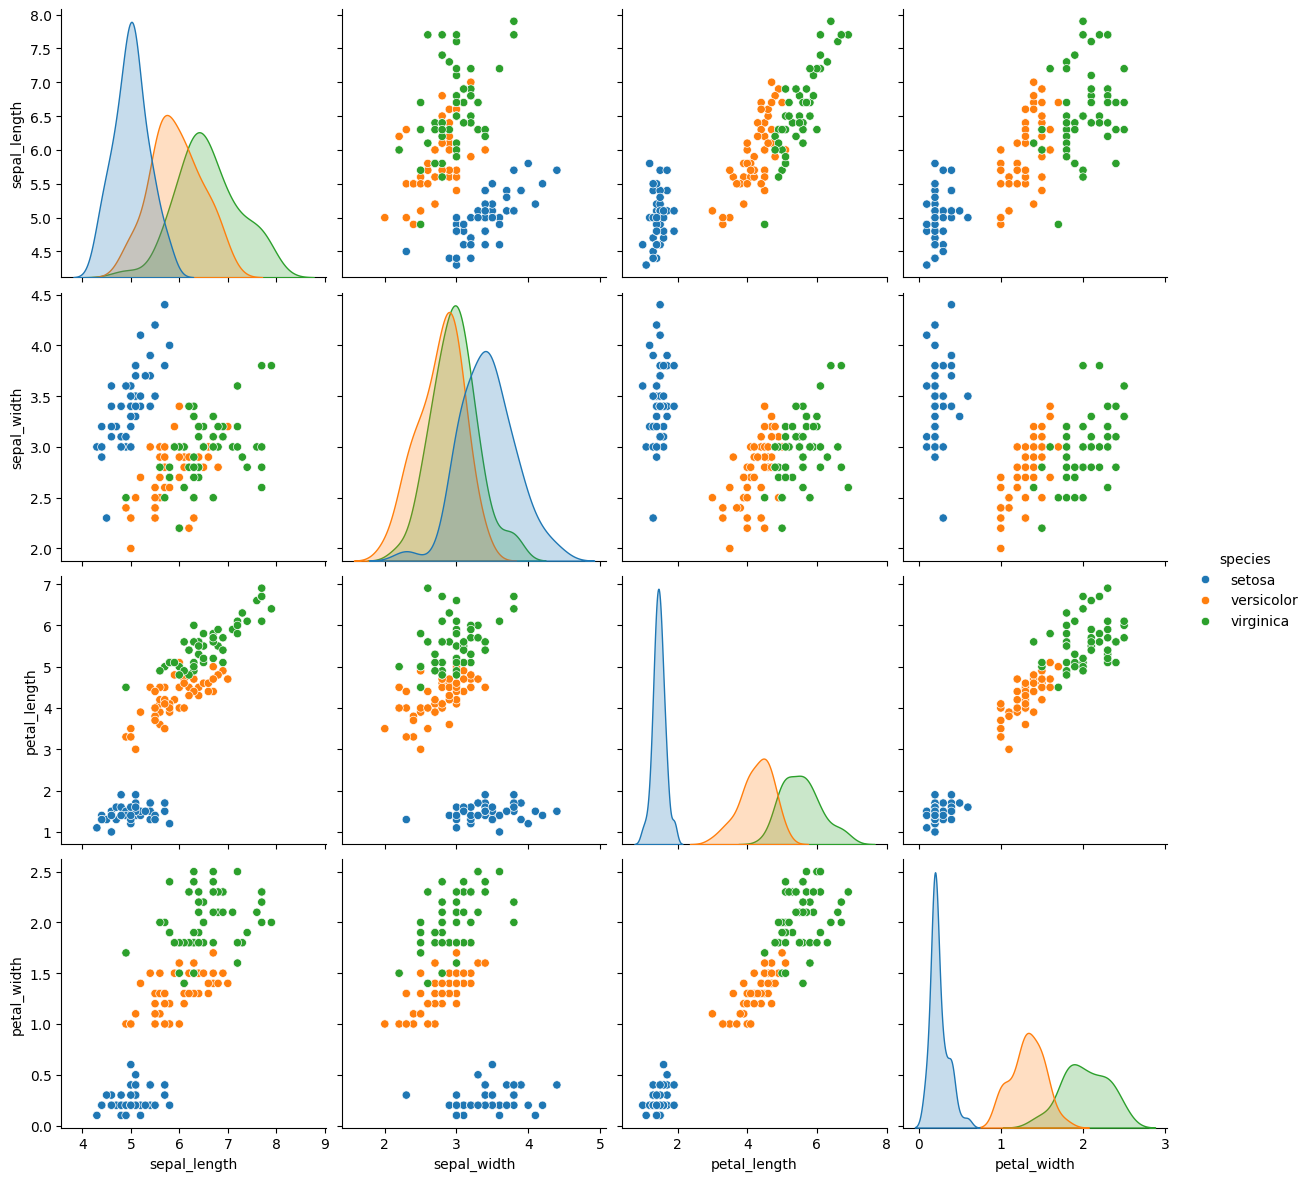

In [24]:
sns.pairplot(data = iris, hue="species", height=3)
plt.show()

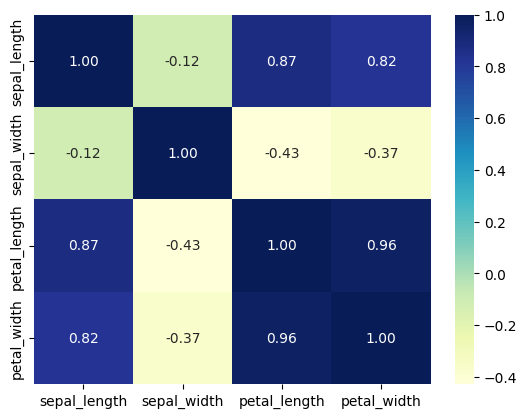

In [26]:
# Plotting heat map
sns.heatmap(iris.drop(columns=['species']).corr(), cmap="YlGnBu", annot=True, fmt=".2f")
plt.show()

2. First use scikit-learn and next use PyTorch to build simple linear regression and do all the neccessary things in machine learning process.

- Feature: petal_length
- Target: petal_width

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split the data into training and testing sets
X = iris[['petal_length']]
y = iris['petal_width']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 1), (30, 1), (120,), (30,))

In [37]:
# Train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [44]:
print(f'The linear model is: Y = {lr.coef_[0]:.4f} * X + {lr.intercept_:.4f}')

The linear model is: Y = 0.4132 * X + -0.3567


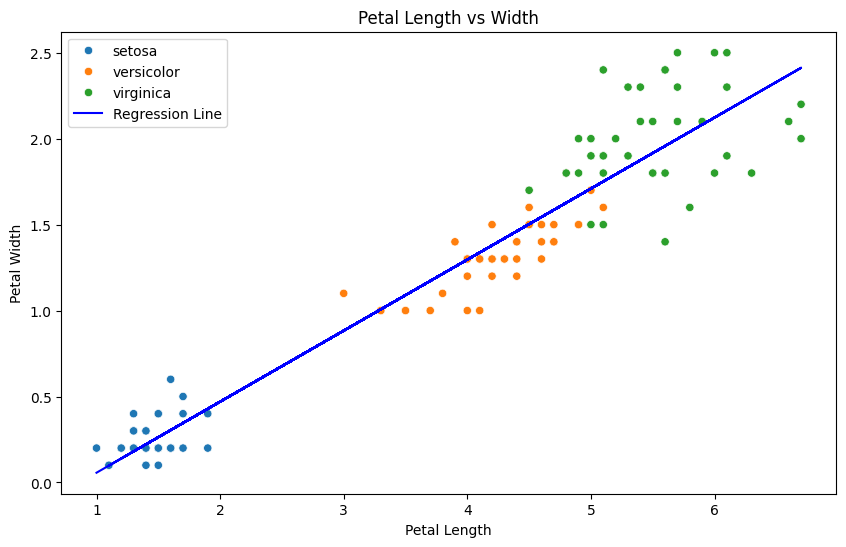

In [54]:
# plot linear regression 
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train['petal_length'], y=y_train, hue=iris.loc[y_train.index, 'species'])
plt.plot(X_train, lr.predict(X_train), color='blue', label='Regression Line')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Petal Length vs Width')
plt.legend()
plt.show()


In [38]:
# Make predictions
y_pred = lr.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Scikit-learn Linear Regression MSE: {mse}')
print(f'Scikit-learn Linear Regression R2: {r2}')

Scikit-learn Linear Regression MSE: 0.045604284097661846
Scikit-learn Linear Regression R2: 0.9282562958836972


2. First use scikit-learn and next use PyTorch to build multiple linear regression and do all the neccessary things in machine learning process.
- Features: petal_length, sepal_length and species
- Target: petal_width

### scikit

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split the data into training and testing sets
X = iris[['petal_length', 'sepal_length']]
y = iris['petal_width']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 2), (30, 2), (120,), (30,))

In [8]:
# Train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [9]:
# Make predictions
y_pred = lr.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Scikit-learn Linear Regression MSE: {mse}')
print(f'Scikit-learn Linear Regression R2: {r2}')

Scikit-learn Linear Regression MSE: 0.04756115495437327
Scikit-learn Linear Regression R2: 0.9251777876576484


### Pytorch

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import pandas as pd

# Load the dataset
# Assuming iris is already loaded in a DataFrame named df
df = iris.copy()

# Encode 'species' as one-hot
encoder = OneHotEncoder()
species_encoded = encoder.fit_transform(df[['species']]).toarray()

# Prepare features and target
X = np.hstack((df[['petal_length', 'sepal_length']].values, species_encoded))
y = df['petal_width'].values

# Normalize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Define the linear regression model
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel(input_dim=X_train_tensor.shape[1])

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [25]:
# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')


Epoch [10/100], Loss: 0.0354
Epoch [20/100], Loss: 0.0339
Epoch [30/100], Loss: 0.0333
Epoch [40/100], Loss: 0.0330
Epoch [50/100], Loss: 0.0329
Epoch [60/100], Loss: 0.0328
Epoch [70/100], Loss: 0.0328
Epoch [80/100], Loss: 0.0328
Epoch [90/100], Loss: 0.0327
Epoch [100/100], Loss: 0.0327


In [14]:
# Evaluate the model
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    test_loss = criterion(predictions, y_test_tensor)
    print(f'Test Loss: {test_loss.item():.4f}')

Test Loss: 0.0352


In [16]:
# Model parameters
print("Model weights:", model.linear.weight.data)
print("Model bias:", model.linear.bias.data)

Model weights: tensor([[ 0.4158, -0.0210, -0.2891, -0.0804,  0.1060]])
Model bias: tensor([1.1238])


In [ ]:
# convert predictions to numpy array (run this only once)
predictions = predictions.numpy()

In [24]:
# print the accuracy
from sklearn.metrics import mean_squared_error, r2_score

# Calculate the mean squared error
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'PyTorch Linear Regression MSE: {mse}')
print(f'PyTorch Linear Regression R2: {r2}')

PyTorch Linear Regression MSE: 0.03520447128047376
PyTorch Linear Regression R2: 0.944617063482273


## Binary Logistic Regression

###  Problem 3

2. First use scikit-learn and next use PyTorch to build binary logistic regression and do all the neccessary things in machine learning process.
- Features: sepal_length, sepal_width, petal_length and petal_width
- Target: species is setosa or not

scikit-learn

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create a binary target variable
iris['is_setosa'] = (iris['species'] == 'setosa').astype(int)

# Features and target variable
X_binary = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y_binary = iris['is_setosa']

In [56]:
iris['is_setosa'].value_counts()

is_setosa
0    100
1     50
Name: count, dtype: int64

In [57]:
# Split the data into training and testing sets
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(X_binary, y_binary, test_size=0.2, random_state=42)

# Train the logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_train_binary, y_train_binary)

LogisticRegression()

In [59]:
# Make predictions
y_pred_binary = log_reg.predict(X_test_binary)

# Evaluate the model
accuracy = accuracy_score(y_test_binary, y_pred_binary)
conf_matrix = confusion_matrix(y_test_binary, y_pred_binary)
class_report = classification_report(y_test_binary, y_pred_binary)

In [61]:
print(f'Scikit-learn Logistic Regression Accuracy: {accuracy:.2f}')

Scikit-learn Logistic Regression Accuracy: 1.00


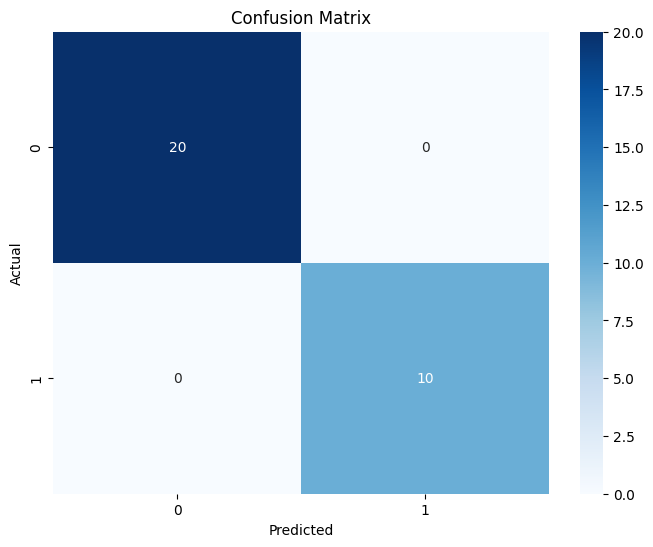

In [64]:
# plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [67]:
print(class_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Pytorch

In [68]:
import torch
from sklearn.preprocessing import StandardScaler

import torch.nn as nn
import torch.optim as optim

# Step 2: Prepare the data
scaler = StandardScaler()
X_train_binary_scaled = scaler.fit_transform(X_train_binary)
X_test_binary_scaled = scaler.transform(X_test_binary)

X_train_tensor = torch.tensor(X_train_binary_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_binary.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_binary_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_binary.values, dtype=torch.float32).view(-1, 1)

X_train_tensor.shape, y_train_tensor.shape, X_test_tensor.shape, y_test_tensor.shape

(torch.Size([120, 4]),
 torch.Size([120, 1]),
 torch.Size([30, 4]),
 torch.Size([30, 1]))

In [69]:
# Step 3: Define the logistic regression model
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

input_dim = X_train_binary.shape[1]
model = LogisticRegressionModel(input_dim)

In [70]:
# Step 4: Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Step 5: Train the model
num_epochs = 1000
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.3064
Epoch [200/1000], Loss: 0.2284
Epoch [300/1000], Loss: 0.1822
Epoch [400/1000], Loss: 0.1517
Epoch [500/1000], Loss: 0.1301
Epoch [600/1000], Loss: 0.1140
Epoch [700/1000], Loss: 0.1015
Epoch [800/1000], Loss: 0.0916
Epoch [900/1000], Loss: 0.0835
Epoch [1000/1000], Loss: 0.0768


In [71]:
# Step 6: Evaluate the model
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    y_pred_binary = (y_pred_tensor.numpy() > 0.5).astype(int)
    accuracy = (y_pred_binary == y_test_tensor.numpy()).mean()
    print(f'PyTorch Logistic Regression Accuracy: {accuracy:.2f}')

PyTorch Logistic Regression Accuracy: 1.00


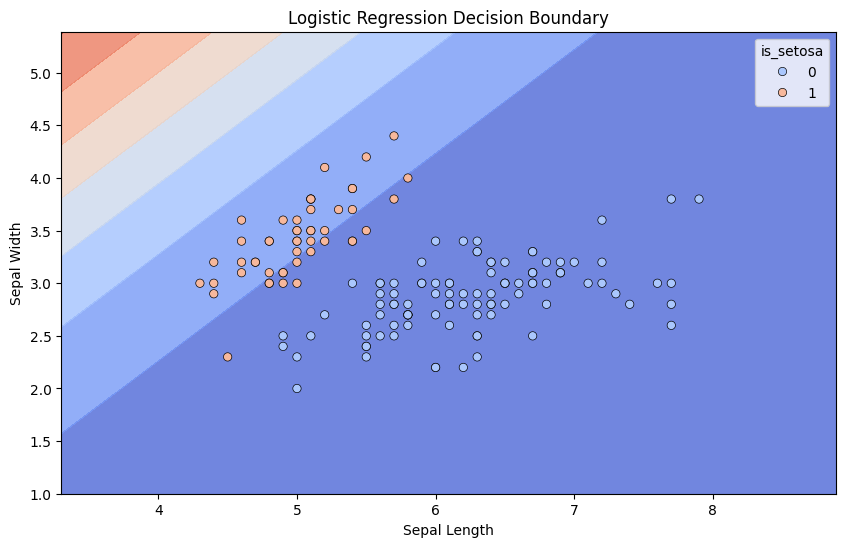

In [82]:
# Generate a mesh grid for plotting decision boundary
x_min, x_max = X_binary.iloc[:, 0].min() - 1, X_binary.iloc[:, 0].max() + 1
y_min, y_max = X_binary.iloc[:, 1].min() - 1, X_binary.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Prepare the grid data for prediction
grid = np.c_[xx.ravel(), yy.ravel(), np.zeros_like(xx.ravel()), np.zeros_like(xx.ravel())]
grid_tensor = torch.tensor(grid, dtype=torch.float32)

# Predict the probabilities for the grid data
model.eval()
with torch.no_grad():
    probs = model(grid_tensor).numpy()

# Reshape the probabilities to match the grid shape
probs = probs.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, probs, alpha=0.8, cmap='coolwarm')
sns.scatterplot(x=X_binary['sepal_length'], y=X_binary['sepal_width'], hue=iris['is_setosa'], palette='coolwarm', edgecolor='k')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Logistic Regression Decision Boundary')
plt.show()

In [83]:
# save the model in pickle file
import pickle

with open('logistic_regression_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# load the model from pickle file
with open('logistic_regression_model.pkl', 'rb') as file:
    model = pickle.load(file)

# Make predictions
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    y_pred_binary = (y_pred_tensor.numpy() > 0.5).astype(int)
    accuracy = (y_pred_binary == y_test_tensor.numpy()).mean()
    print(f'PyTorch Logistic Regression Accuracy: {accuracy:.2f}')
    

PyTorch Logistic Regression Accuracy: 1.00


3. Build and deploy streamlit web application(or any other framework)with both input features output prediction are in raw data.

In [2]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import joblib

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the logistic regression model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")

# Save the model
joblib.dump(model, 'iris_model.pkl')


Model Accuracy: 1.00


['iris_model.pkl']

## Multi-Class Logistic Regression

### Problem 4

 1. Do anexploratory data analysis on the penguins dataset from seaborn library.

In [2]:
# Load the penguins dataset
penguins = sns.load_dataset('penguins')

# Display the first few rows of the dataset
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


![df](https://datasciencebox.org/course-materials/_slides/u2-d02-ggplot2/img/penguins.png){ width=50% }

In [3]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [6]:
penguins.isnull().sum()/len(penguins) * 100

species              0.000000
island               0.000000
bill_length_mm       0.581395
bill_depth_mm        0.581395
flipper_length_mm    0.581395
body_mass_g          0.581395
sex                  3.197674
dtype: float64

In [7]:
penguins.dropna(inplace=True)

In [8]:
penguins.isnull().sum()/len(penguins) * 100

species              0.0
island               0.0
bill_length_mm       0.0
bill_depth_mm        0.0
flipper_length_mm    0.0
body_mass_g          0.0
sex                  0.0
dtype: float64

Number of data points in each species


species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

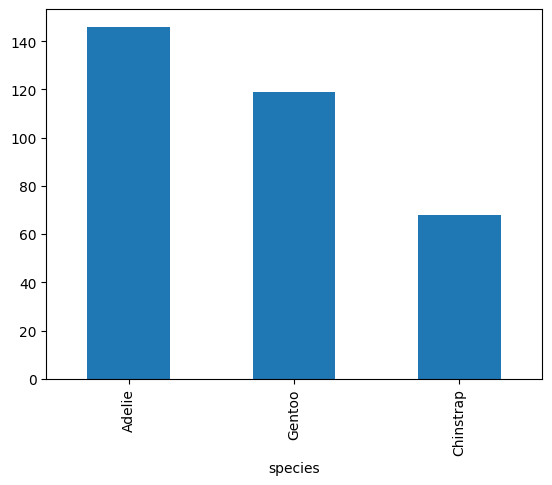

In [9]:
# Different types of species we have
# Number of data points we have for each species.
print("Number of data points in each species")
penguins['species'].value_counts().plot(kind = 'bar')
penguins['species'].value_counts()

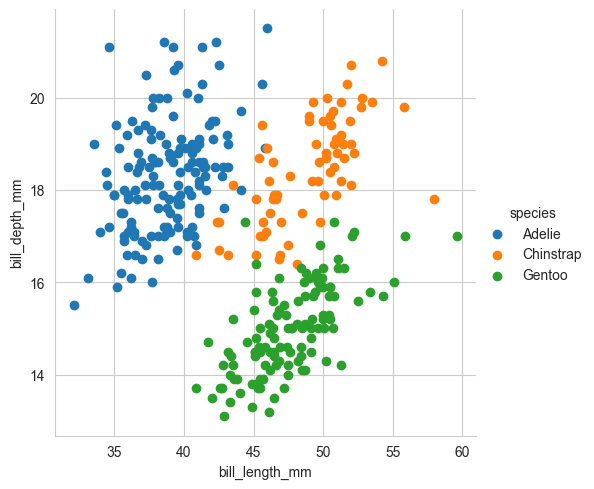

In [13]:
sns.set_style('whitegrid')
sns.FacetGrid(penguins, hue ="species", height =5)\
   .map(plt.scatter,"bill_length_mm","bill_depth_mm")\
   .add_legend();
plt.show()

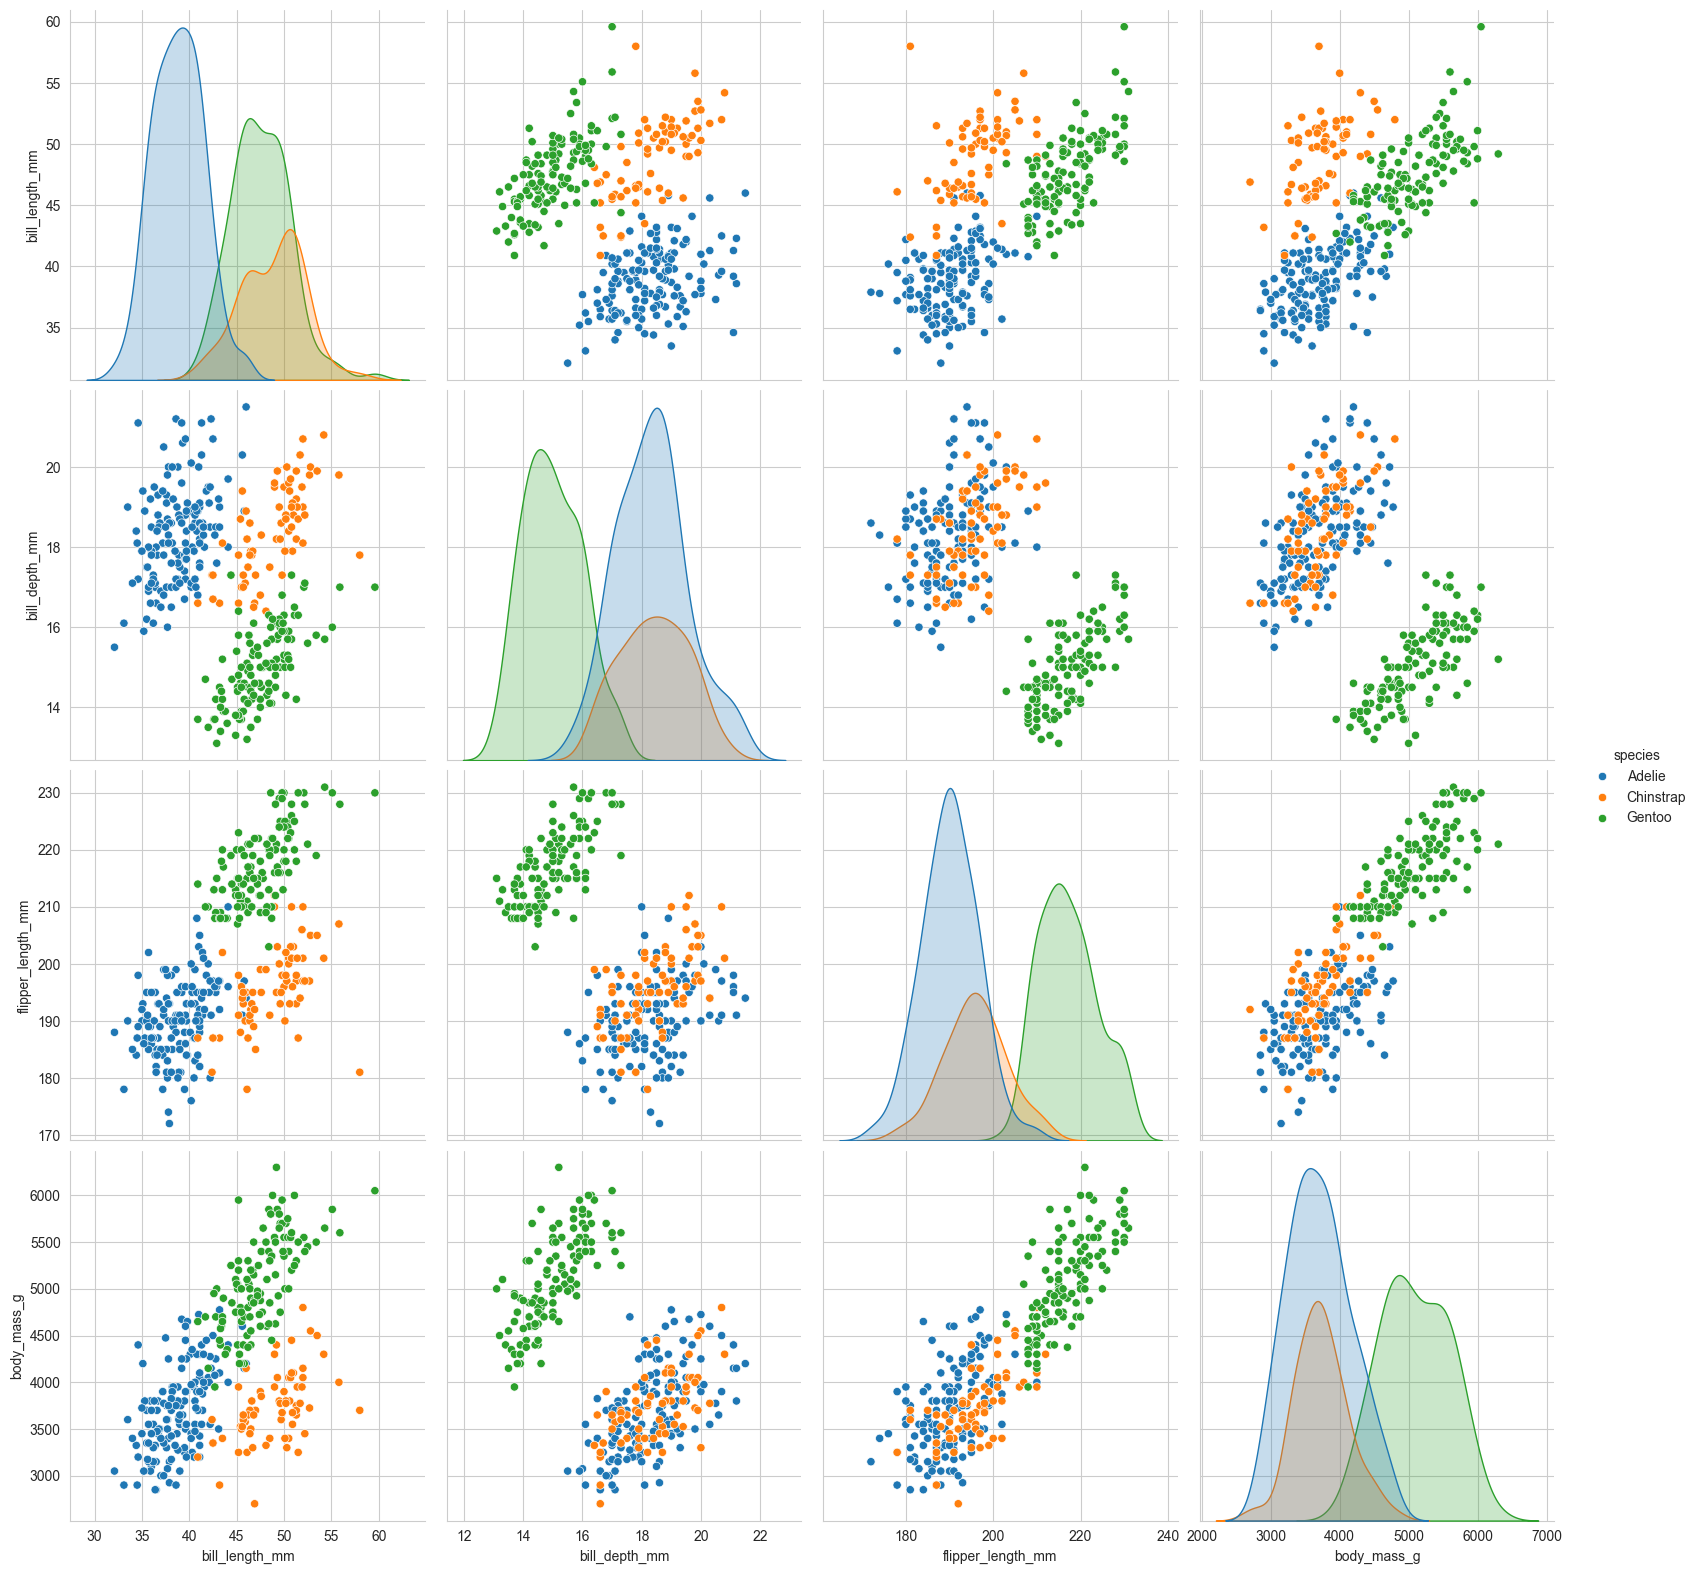

In [15]:
plt.close();
sns.set_style("whitegrid");
sns.pairplot(penguins, hue='species', height=4);
plt.show()

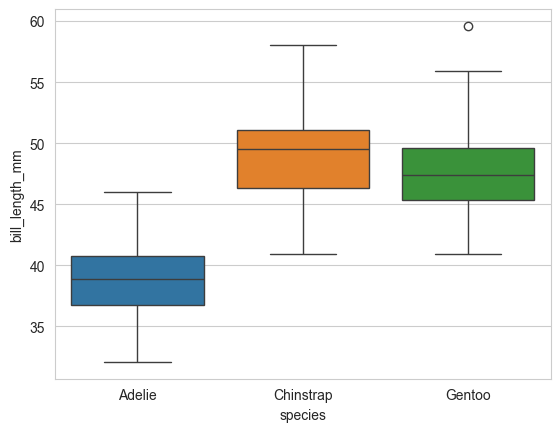

In [20]:
sns.boxplot(x = 'species', y='bill_length_mm', data = penguins, hue = 'species')
plt.show()

Which island consists of most Penguins?


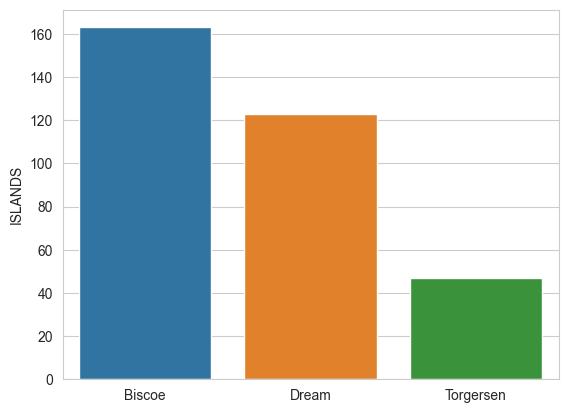

In [29]:
print('Which island consists of most Penguins?')

df = penguins['island'].value_counts().reset_index()
df.columns = ['island', 'count']

fig = sns.barplot(data=df, x='island', y='count', hue='island')
fig.set(xlabel='', ylabel='ISLANDS')
plt.show()

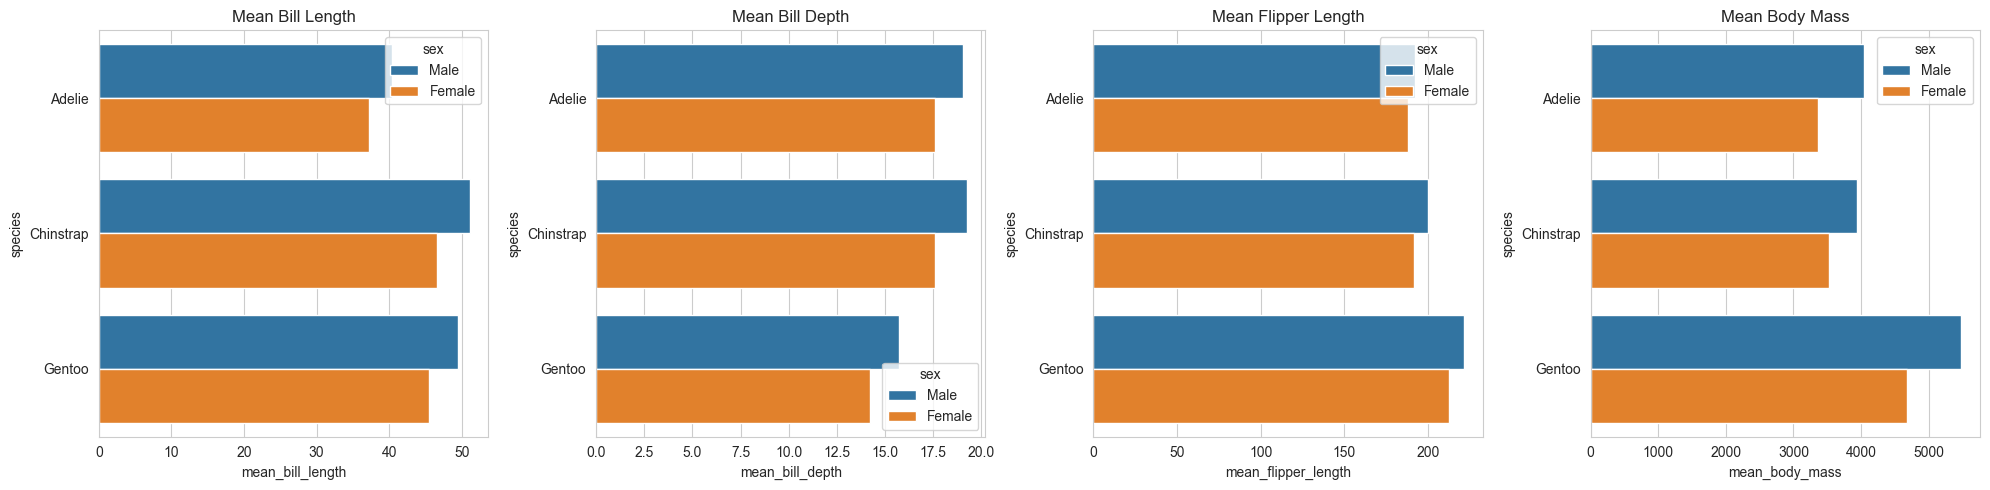

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Bill Length
sns.barplot(data=df, x='mean_bill_length', y='species', hue='sex', ax=axes[0])
axes[0].set_title('Mean Bill Length')

# Bill Depth
df['mean_bill_depth'] = penguins.groupby(['species', 'sex'])['bill_depth_mm'].transform('mean')
df_depth = df.drop('mean_bill_length', axis=1).drop_duplicates()
sns.barplot(data=df_depth, x='mean_bill_depth', y='species', hue='sex', ax=axes[1])
axes[1].set_title('Mean Bill Depth')

# Flipper Length
df['mean_flipper_length'] = penguins.groupby(['species', 'sex'])['flipper_length_mm'].transform('mean')
df_flipper = df.drop(['mean_bill_length', 'mean_bill_depth'], axis=1).drop_duplicates()
sns.barplot(data=df_flipper, x='mean_flipper_length', y='species', hue='sex', ax=axes[2])
axes[2].set_title('Mean Flipper Length')

# Body Mass
df['mean_body_mass'] = penguins.groupby(['species', 'sex'])['body_mass_g'].transform('mean')
df_body_mass = df.drop(['mean_bill_length', 'mean_bill_depth', 'mean_flipper_length'], axis=1).drop_duplicates()
sns.barplot(data=df_body_mass, x='mean_body_mass', y='species', hue='sex', ax=axes[3])
axes[3].set_title('Mean Body Mass')

plt.tight_layout()
plt.show()

2. First use scikit-learn and next use PyTorch to build multi-class logistic regression and do all the neccessary things in machine learning process.
- Features:
 `island`, `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`, `sex`
- Target: `species`

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Define features and target
X = penguins[['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']]
y = penguins['species']

# Preprocessing for numerical data
numerical_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())])

# Preprocessing for categorical data
categorical_features = ['island', 'sex']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])

# Create a pipeline that combines preprocessing and model training
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', LogisticRegression(max_iter=200))])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
# Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bill_length_mm',
                                                   'bill_depth_mm',
                                                   'flipper_length_mm',
                                                   'body_mass_g']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['island', 'sex'])])),
                ('classifier', LogisticRegression(max_iter=200))])

In [35]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Multi-Class Logistic Regression Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(class_report)

Multi-Class Logistic Regression Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        31
   Chinstrap       1.00      1.00      1.00        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



In [36]:
import torch
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

import torch.nn as nn
import torch.optim as optim

# Preprocessing for numerical data
numerical_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())])

# Preprocessing for categorical data
categorical_features = ['island', 'sex']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])

# Preprocess the features
X_preprocessed = preprocessor.fit_transform(X)

# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Convert to tensors
X_tensor = torch.tensor(X_preprocessed, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

# Split the data into training and testing sets
X_train_tensor, X_test_tensor = X_tensor[:266], X_tensor[266:]
y_train_tensor, y_test_tensor = y_tensor[:266], y_tensor[266:]

# Define the logistic regression model
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x)

In [37]:
input_dim = X_train_tensor.shape[1]
output_dim = len(label_encoder.classes_)
model = LogisticRegressionModel(input_dim, output_dim)

In [38]:
# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Train the model
num_epochs = 1000
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.5965
Epoch [200/1000], Loss: 0.3984
Epoch [300/1000], Loss: 0.3066
Epoch [400/1000], Loss: 0.2517
Epoch [500/1000], Loss: 0.2147
Epoch [600/1000], Loss: 0.1880
Epoch [700/1000], Loss: 0.1678
Epoch [800/1000], Loss: 0.1519
Epoch [900/1000], Loss: 0.1391
Epoch [1000/1000], Loss: 0.1285


In [39]:
# Evaluate the model
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    _, y_pred = torch.max(y_pred_tensor, 1)
    accuracy = (y_pred == y_test_tensor).sum().item() / y_test_tensor.size(0)
    print(f'PyTorch Multi-Class Logistic Regression Accuracy: {accuracy:.2f}')

PyTorch Multi-Class Logistic Regression Accuracy: 1.00


 3. Select only some important features with reasonable tools and reasonings and repeat question 2.

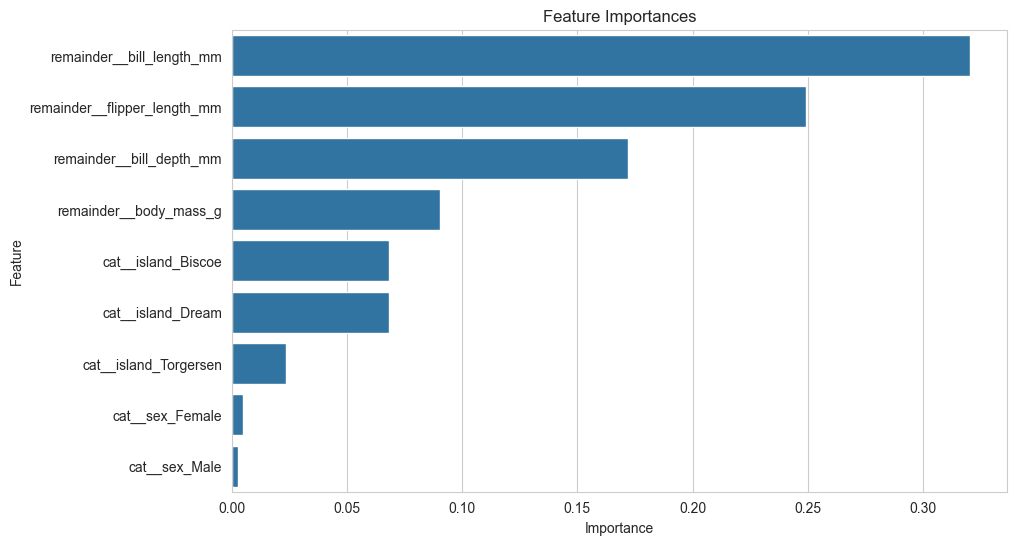

In [41]:
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define the preprocessing for categorical features
categorical_features = ['island', 'sex']
categorical_transformer = Pipeline(steps=[
	('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
	transformers=[
		('cat', categorical_transformer, categorical_features)],
	remainder='passthrough')

# Preprocess the training data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Train a RandomForestClassifier to get feature importances
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_preprocessed, y_train)

# Get feature importances
importances = rf.feature_importances_
features = preprocessor.get_feature_names_out()

# Create a DataFrame for visualization
feature_importances = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importances')
plt.show()

# Select top features
top_features = feature_importances['Feature'].head(4).tolist()
X_train_selected = X_train_preprocessed[:, :4]
X_test_selected = X_test_preprocessed[:, :4]

In [55]:
# Define features and target
X_selected = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']]
y = penguins['species']

# Preprocessing for numerical data
numerical_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features)])

# Create a pipeline that combines preprocessing and model training
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', LogisticRegression(max_iter=200))])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Multi-Class Logistic Regression Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(class_report)

Multi-Class Logistic Regression Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        31
   Chinstrap       1.00      1.00      1.00        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



In [50]:
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch.nn as nn
import torch.optim as optim

# Define features and target
X_selected = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']]
y = penguins['species']

# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Convert to tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

# Split the data into training and testing sets
X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# Define the logistic regression model
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x)

input_dim = X_train_tensor.shape[1]
output_dim = len(label_encoder.classes_)
model = LogisticRegressionModel(input_dim, output_dim)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [51]:
# Train the model
num_epochs = 1000
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.4768
Epoch [200/1000], Loss: 0.3609
Epoch [300/1000], Loss: 0.3020
Epoch [400/1000], Loss: 0.2655
Epoch [500/1000], Loss: 0.2402
Epoch [600/1000], Loss: 0.2213
Epoch [700/1000], Loss: 0.2065
Epoch [800/1000], Loss: 0.1945
Epoch [900/1000], Loss: 0.1844
Epoch [1000/1000], Loss: 0.1759


In [53]:

# Evaluate the model
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    _, y_pred = torch.max(y_pred_tensor, 1)
    accuracy = (y_pred == y_test_tensor).sum().item() / y_test_tensor.size(0)
    print(f'PyTorch Multi-Class Logistic Regression Accuracy: {accuracy:.4f}')

PyTorch Multi-Class Logistic Regression Accuracy: 0.9851


4. Build and deploy streamlit web application(or any other framework) with both input features output prediction are in raw data.

In [56]:
import joblib

# Save the trained model to a file
joblib.dump(model, 'penguins_logistic_regression_model.pkl')
print("Model saved successfully!")


Model saved successfully!


## Regression

### Problem 5

 1. Do anexploratory data analysis on the mpg dataset from seaborn.

In [2]:
# Load the mpg dataset
mpg = sns.load_dataset('mpg')

# Display the first few rows of the dataset
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [8]:
mpg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           392 non-null    float64 
 1   cylinders     392 non-null    int64   
 2   displacement  392 non-null    float64 
 3   horsepower    392 non-null    float64 
 4   weight        392 non-null    int64   
 5   acceleration  392 non-null    float64 
 6   model_year    392 non-null    int64   
 7   origin        392 non-null    category
 8   name          392 non-null    object  
dtypes: category(1), float64(4), int64(3), object(1)
memory usage: 28.1+ KB


In [5]:
mpg.dropna(inplace=True)

In [9]:
mpg['model_year'] = mpg['model_year'].astype('category')
mpg['origin'] = mpg['origin'].astype('category')

In [10]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000


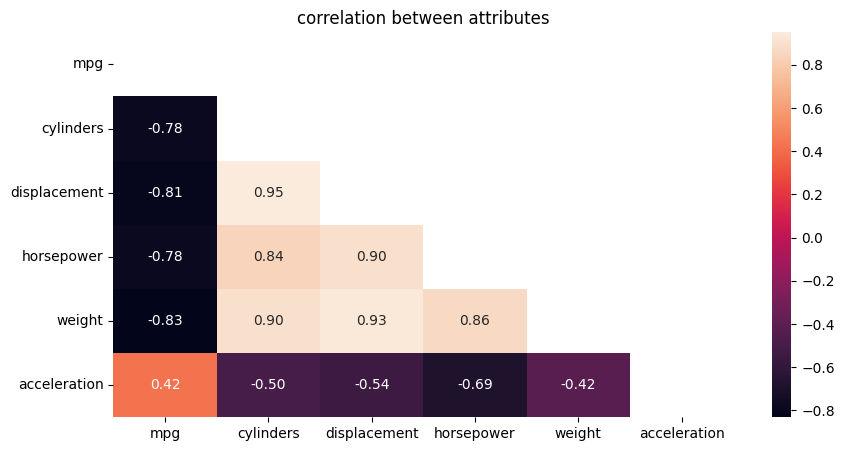

In [18]:
# plotting correlation heatmap
plt.figure(figsize=(10,5))
corr = mpg.select_dtypes(include=[float, int]).corr()
mask = np.triu(corr)
sns.heatmap(corr, annot=True, mask=mask, fmt='.2f')
plt.title("correlation between attributes")
plt.show()

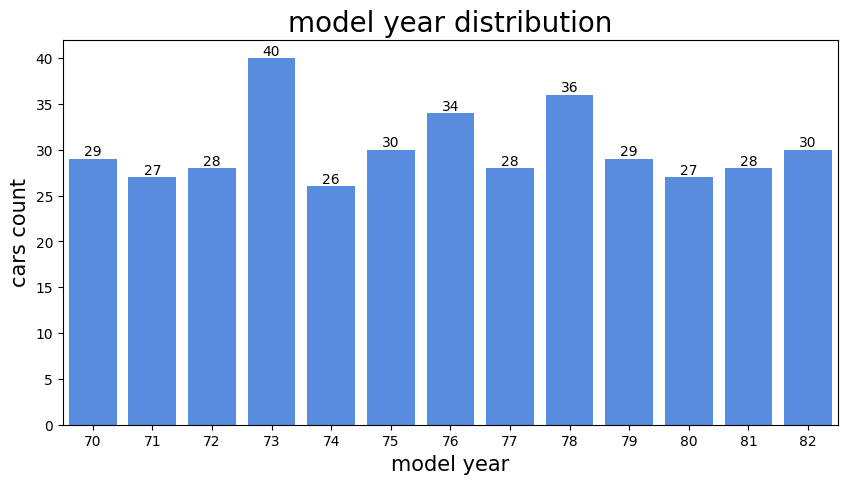

In [25]:
# displaying histgram of model year column
plt.figure(figsize=(10,5))
ax = sns.countplot(x = 'model_year', data = mpg, color = '#4287f5')
ax.bar_label(ax.containers[0], label_type='edge')
plt.title("model year distribution", fontsize = 20)
plt.xlabel("model year", fontsize = 15)
plt.ylabel("cars count", fontsize = 15)
plt.show()

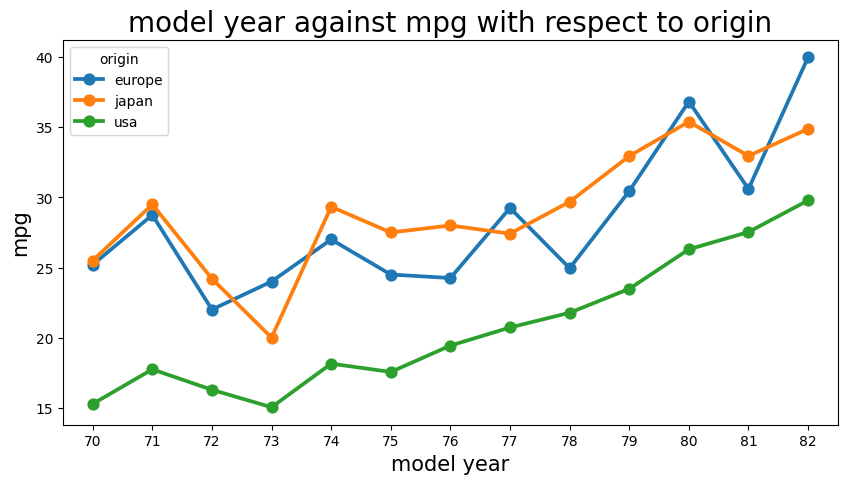

In [40]:
# display model year against mpg with respect to origin
plt.figure(figsize=(10,5))
sns.pointplot(x = 'model_year', y = 'mpg', hue = 'origin', data = mpg, errorbar=None);
plt.title("model year against mpg with respect to origin", fontsize = 20)
plt.xlabel("model year", fontsize = 15)
plt.ylabel("mpg", fontsize = 15)
plt.show()

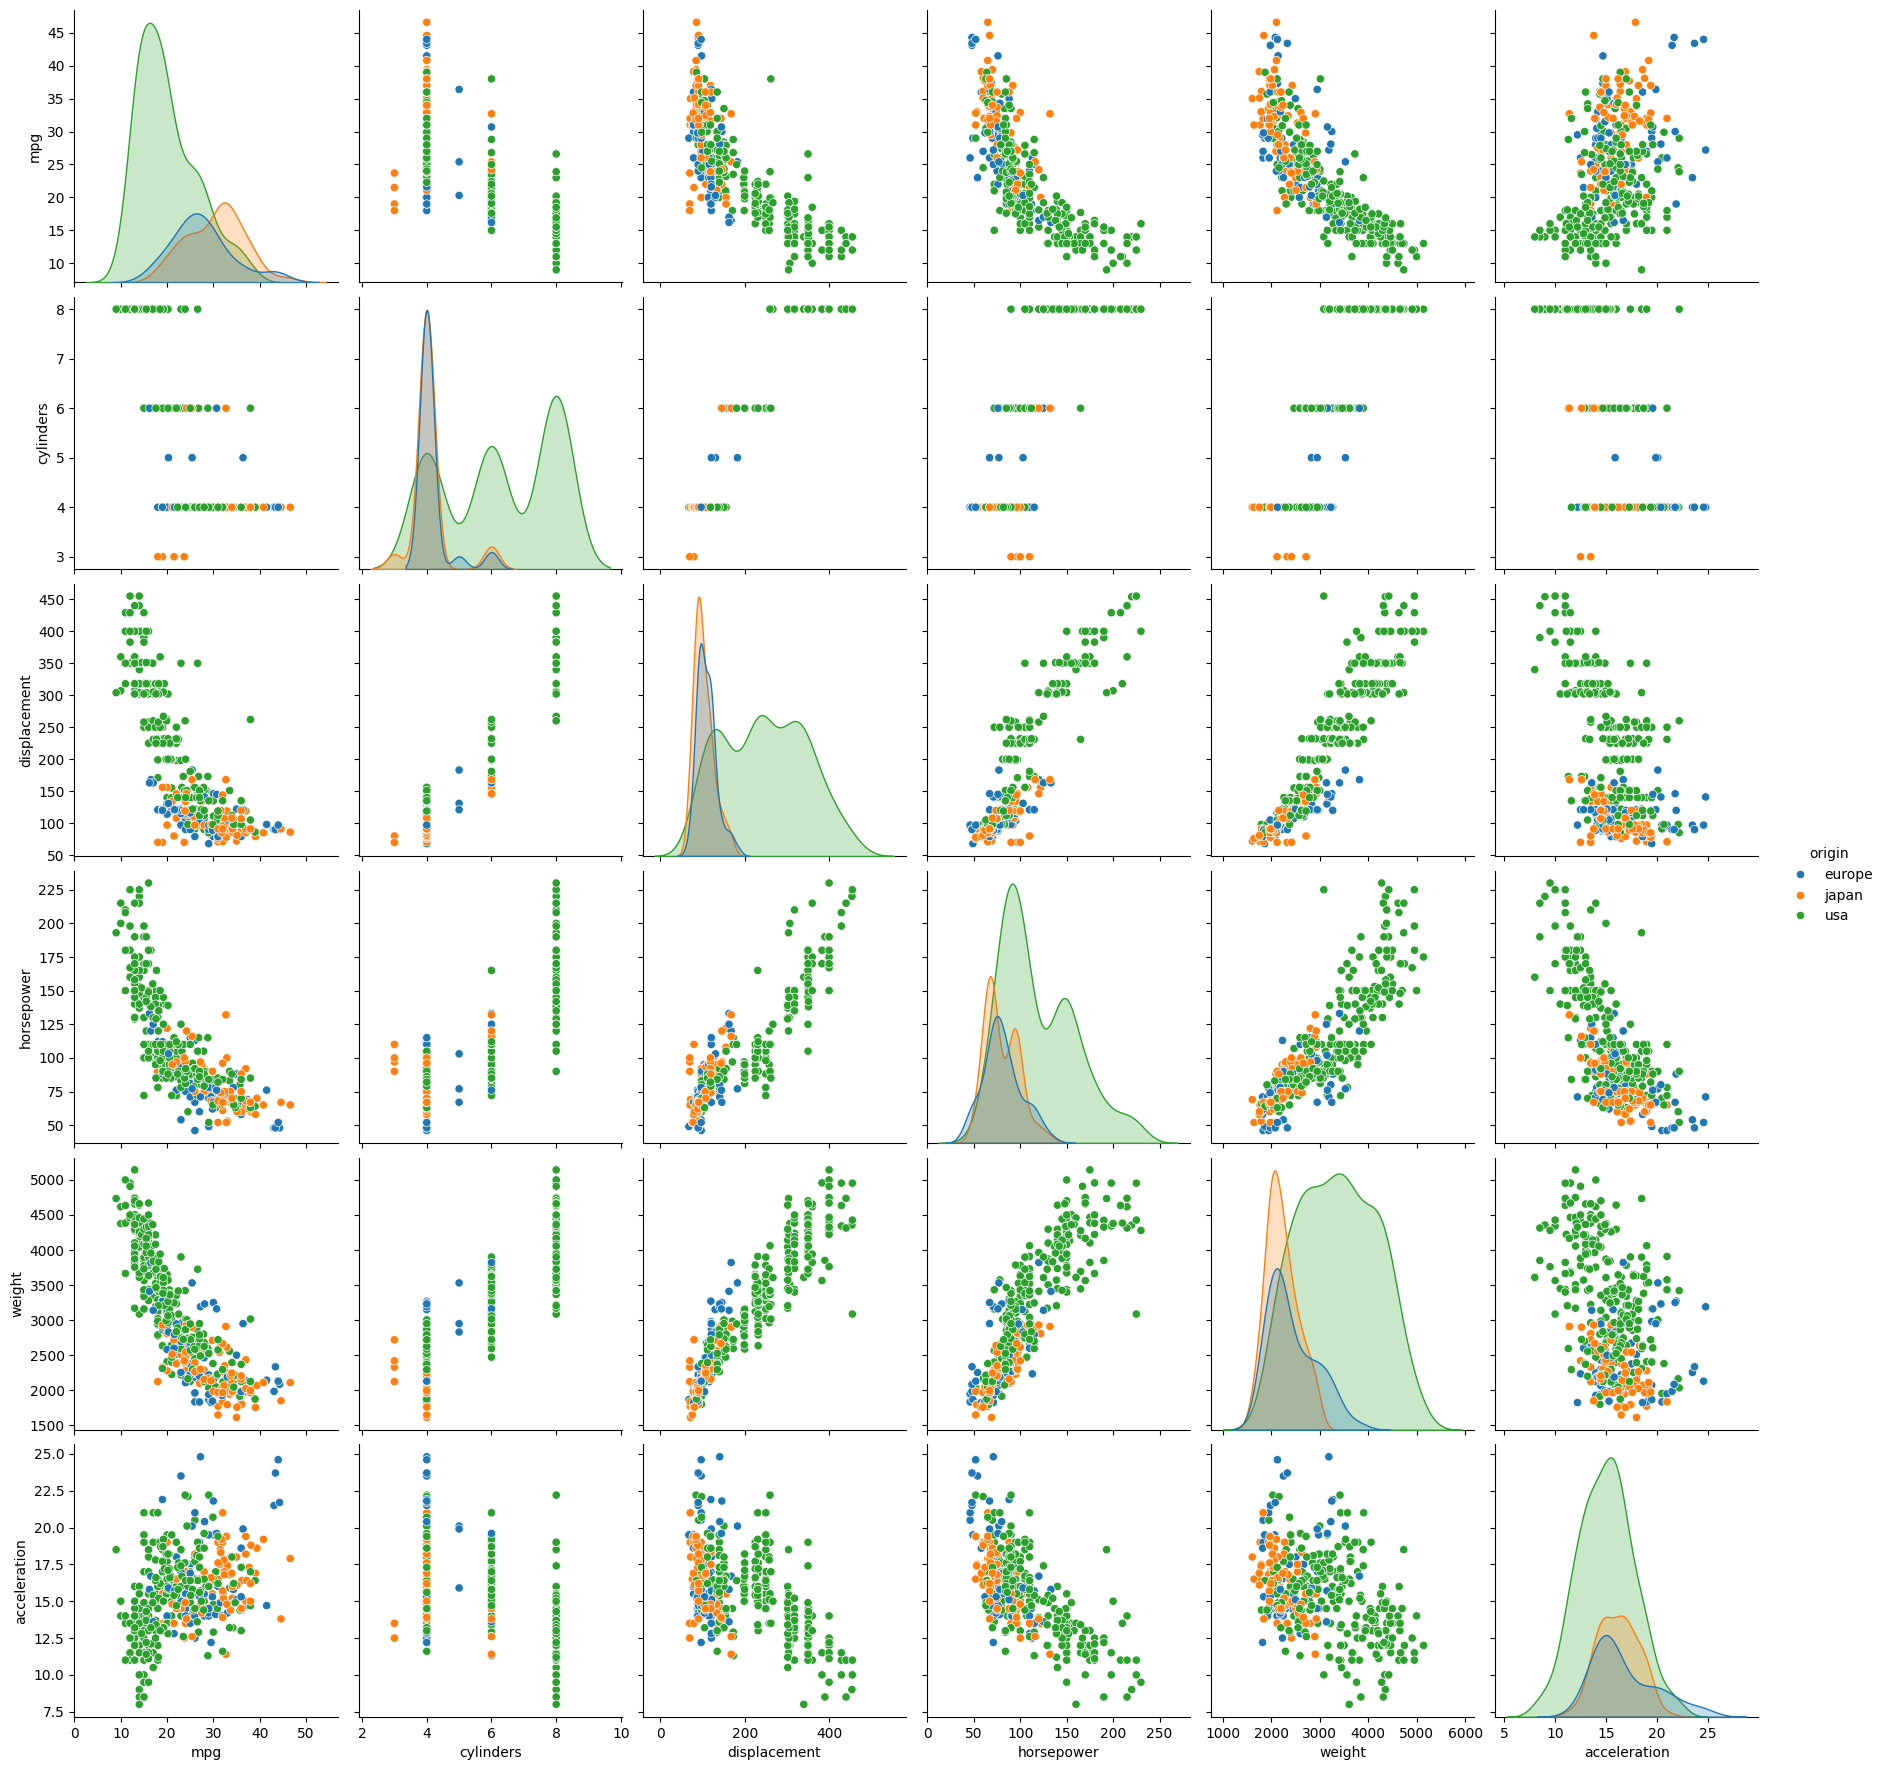

In [27]:
sns.pairplot(mpg, hue='origin', height=3)
plt.show()

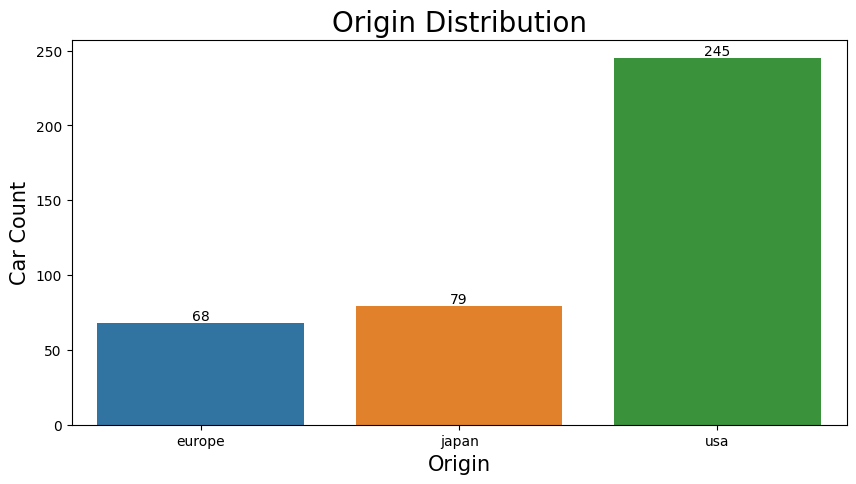

In [37]:
# plotting cars origin distribution
plt.figure(figsize=(10,5))
ax = sns.countplot(x='origin', data=mpg, hue='origin')
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
plt.title("Origin Distribution", fontsize=20)
plt.xlabel("Origin", fontsize=15)
plt.ylabel("Car Count", fontsize=15)
plt.show()

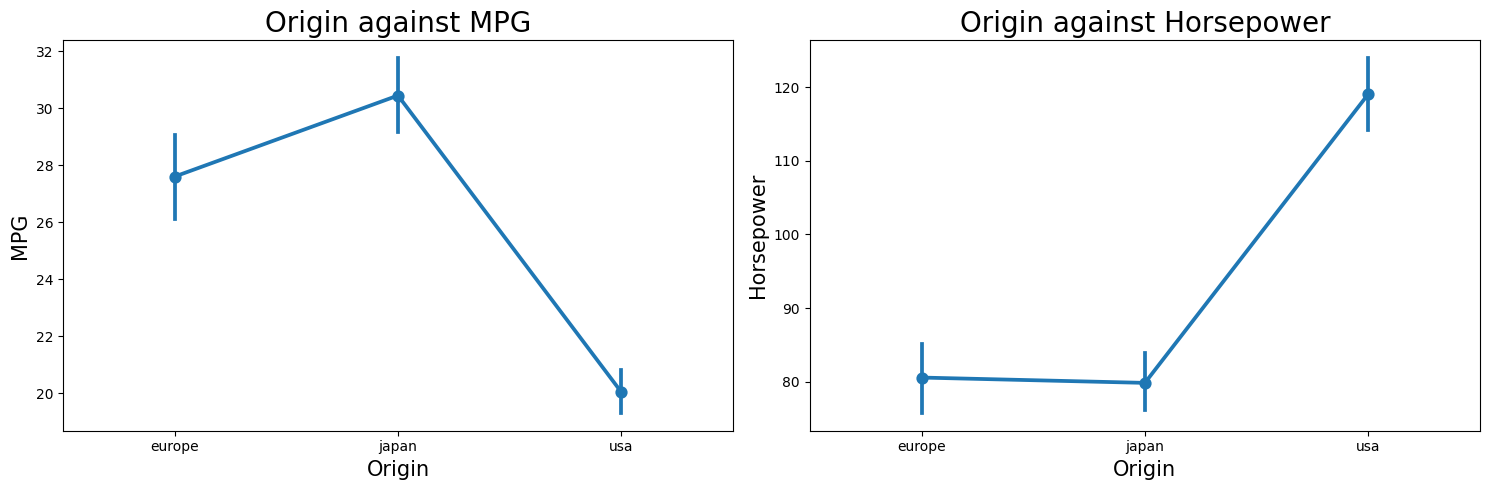

In [45]:
# Plotting origin against mpg and horsepower in a 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plotting origin against mpg
sns.pointplot(ax=axes[0], x='origin', y='mpg', data=mpg)
axes[0].set_title("Origin against MPG", fontsize=20)
axes[0].set_xlabel("Origin", fontsize=15)
axes[0].set_ylabel("MPG", fontsize=15)

# Plotting origin against horsepower
sns.pointplot(ax=axes[1], x='origin', y='horsepower', data=mpg)
axes[1].set_title("Origin against Horsepower", fontsize=20)
axes[1].set_xlabel("Origin", fontsize=15)
axes[1].set_ylabel("Horsepower", fontsize=15)

plt.tight_layout()
plt.show()

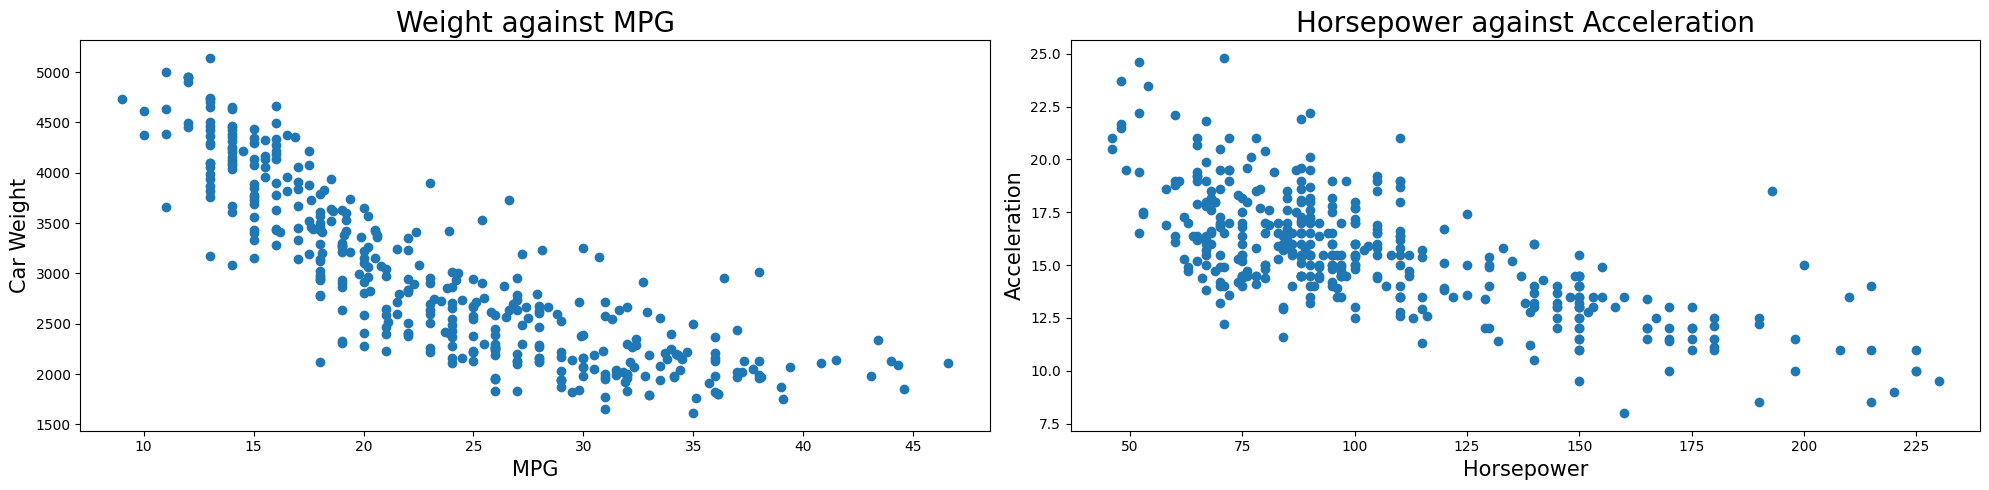

In [47]:
# Create a 1x2 grid for the plots
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Plotting weight against mpg
axes[0].scatter(mpg['mpg'], mpg['weight'])
axes[0].set_title("Weight against MPG", fontsize=20)
axes[0].set_xlabel("MPG", fontsize=15)
axes[0].set_ylabel("Car Weight", fontsize=15)

# Plotting horsepower against acceleration
axes[1].scatter(mpg['horsepower'], mpg['acceleration'])
axes[1].set_title("Horsepower against Acceleration", fontsize=20)
axes[1].set_xlabel("Horsepower", fontsize=15)
axes[1].set_ylabel("Acceleration", fontsize=15)

# Adjust layout
plt.tight_layout()
plt.show()

**Conclusion**
In this section, we'd add the conclusions we draw from the previous visualisations.

- As years pass after 1973, there has been a noticable increase in mpg.
- As cylinders in the engine increases above 4, MPG decreases and engine horsepower increases. That indicates negative correlation between mpg and horsepower.
- mpg increases as weight decreses over time, that also indecates a stron correlation between them.
- Althogh USA has the biggest count of produced cars, its cars has relatively very low mpg, thus the highest possible weight compared to Asia and Europe
- Asia is the leading contry in producing cars with high mpg with a mean close to 30, and it produces the lightest cars
- We can spot a negative correlation between acceleration and horepower, this means that it has a positive one with mpg.

 2. First use scikit-learn and next use PyTorch to build binary logistic regression and do all the neccessary things in machine learning process.
- Target: `mpg`
- Features: Use appropriate tools and reasoning to choose the important features for the model

In [49]:
# Find the important features to predict mpg
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Define the preprocessing for categorical features
categorical_features = ['model_year', 'origin']
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)],
    remainder='passthrough')

# Define features and target
X = mpg.drop(columns=['mpg', 'name'])
y = mpg['mpg']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess the training data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Train a RandomForestRegressor to get feature importances
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_preprocessed, y_train)


RandomForestRegressor(random_state=42)

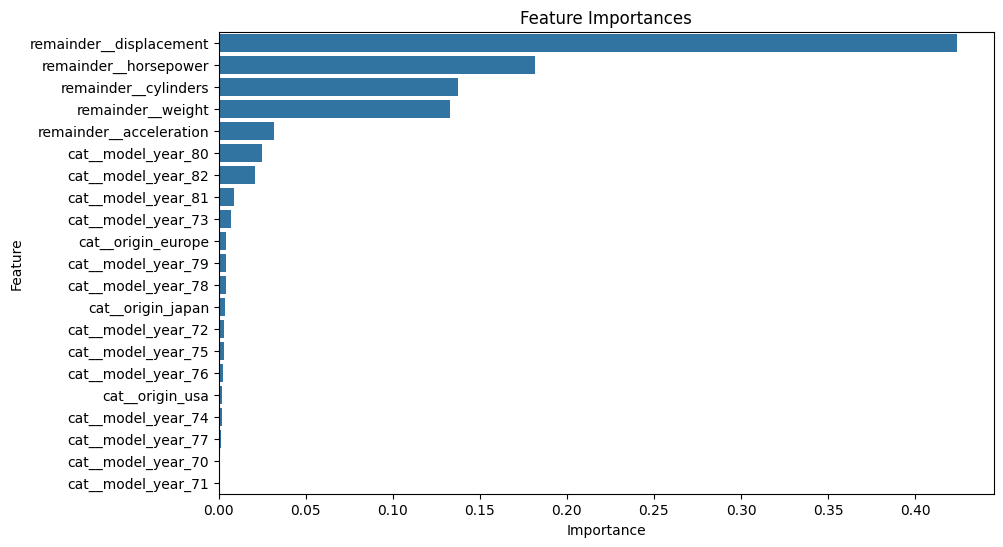

In [50]:
# Get feature importances
importances = rf.feature_importances_
features = preprocessor.get_feature_names_out()

# Create a DataFrame for visualization
feature_importances = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importances')
plt.show()

In [52]:

from sklearn.decomposition import PCA

# Standardize the data
scaler = StandardScaler()
scaled_mpg_data = scaler.fit_transform(mpg.select_dtypes(include=[float, int]))

# Perform PCA
pca_mpg = PCA()
pca_mpg.fit(scaled_mpg_data)

PCA()

In [53]:
# Compute the loadings (contribution of original variables on the first two PCs)
loadings_mpg = pca_mpg.components_.T * np.sqrt(pca_mpg.explained_variance_)

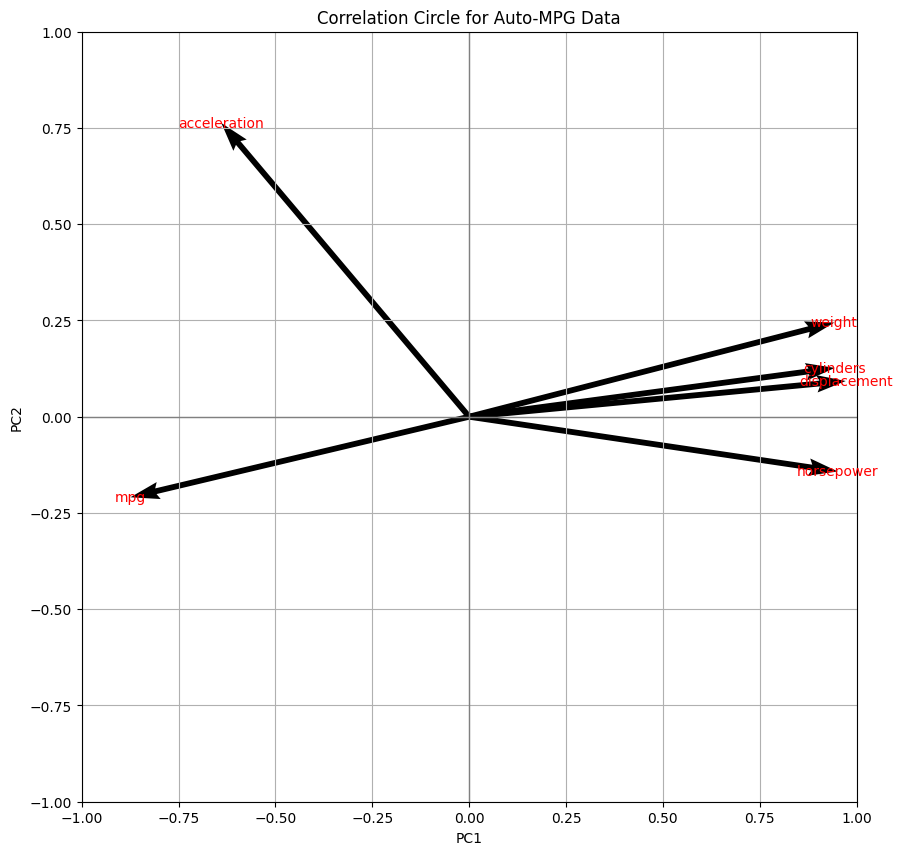

In [54]:
# Create a correlation circle
plt.figure(figsize=(10, 10))
plt.quiver(np.zeros(loadings_mpg.shape[0]), np.zeros(loadings_mpg.shape[0]), loadings_mpg[:, 0], loadings_mpg[:, 1], 
           angles='xy', scale_units='xy', scale=1)
for i, var in enumerate(mpg.select_dtypes(include=[float, int]).columns):
    plt.text(loadings_mpg[i, 0], loadings_mpg[i, 1], var, color='r', ha='center', va='center')

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Correlation Circle for Auto-MPG Data')
plt.grid()
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.show()

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Convert the target variable into binary classification
median_mpg = mpg['mpg'].median()
mpg['high_mpg'] = (mpg['mpg'] > median_mpg).astype(int)

# Define features and target
X_binary = mpg[['cylinders', 'acceleration']]
y_binary = mpg['high_mpg']

# Split the data into training and testing sets
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(X_binary, y_binary, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_binary_scaled = scaler.fit_transform(X_train_binary)
X_test_binary_scaled = scaler.transform(X_test_binary)

# Train the logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_train_binary_scaled, y_train_binary)

# Make predictions
y_pred_binary = log_reg.predict(X_test_binary_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test_binary, y_pred_binary)
class_report = classification_report(y_test_binary, y_pred_binary)

print(f'Scikit-learn Logistic Regression Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(class_report)

Scikit-learn Logistic Regression Accuracy: 0.90
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90        42
           1       0.84      0.97      0.90        37

    accuracy                           0.90        79
   macro avg       0.90      0.90      0.90        79
weighted avg       0.91      0.90      0.90        79



In [57]:
# Example new data for testing
new_data = pd.DataFrame({
    'cylinders': [4, 6, 8],
    'acceleration': [15.0, 12.0, 10.0]
})

# Standardize the new data
new_data_scaled = scaler.transform(new_data)

# Make predictions
new_predictions = log_reg.predict(new_data_scaled)

# Print the predictions
print("Predictions for new data:", new_predictions)

Predictions for new data: [1 0 0]


5. Build and deploy streamlit web application(or any other framework) with both input features output prediction are in raw data.

In [59]:
import joblib

# Save the trained logistic regression model
joblib.dump(log_reg, 'mpg_logistic_regression_model.pkl')
joblib.dump(scaler, 'mpg_scaler.pkl')


['mpg_scaler.pkl']

##  Problem 6

###  1. Do anexploratory data analysis on the car dataset from UCI machine learning reposity.

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
car_evaluation = fetch_ucirepo(id=19) 
  
# data (as pandas dataframes) 
X = car_evaluation.data.features 
y = car_evaluation.data.targets 

In [5]:
car_evaluation_df = pd.concat([X, y], axis=1)
car_evaluation_df 

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good


| Variable Name | Role    | Type         | Description                                  |
|---------------|---------|--------------|----------------------------------------------|
| buying        | Feature | Categorical  | Buying price                                 |
| maint         | Feature | Categorical  | Price of the maintenance                    |
| doors         | Feature | Categorical  | Number of doors                             |
| persons       | Feature | Categorical  | Capacity in terms of persons to carry       |
| lug_boot      | Feature | Categorical  | The size of luggage boot                    |
| safety        | Feature | Categorical  | Estimated safety of the car                 |
| class         | Target  | Categorical  | Evaluation level (unacceptable, acceptable, good, very good) |


In [6]:
car_evaluation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [7]:
car_evaluation_df['buying'] = car_evaluation_df['buying'].astype('category')
car_evaluation_df['maint'] = car_evaluation_df['maint'].astype('category')
car_evaluation_df['lug_boot'] = car_evaluation_df['lug_boot'].astype('category')
car_evaluation_df['safety'] = car_evaluation_df['safety'].astype('category')
car_evaluation_df['class'] = car_evaluation_df['class'].astype('category')
car_evaluation_df['doors'] = car_evaluation_df['doors'].astype('category')
car_evaluation_df['persons'] = car_evaluation_df['persons'].astype('category')

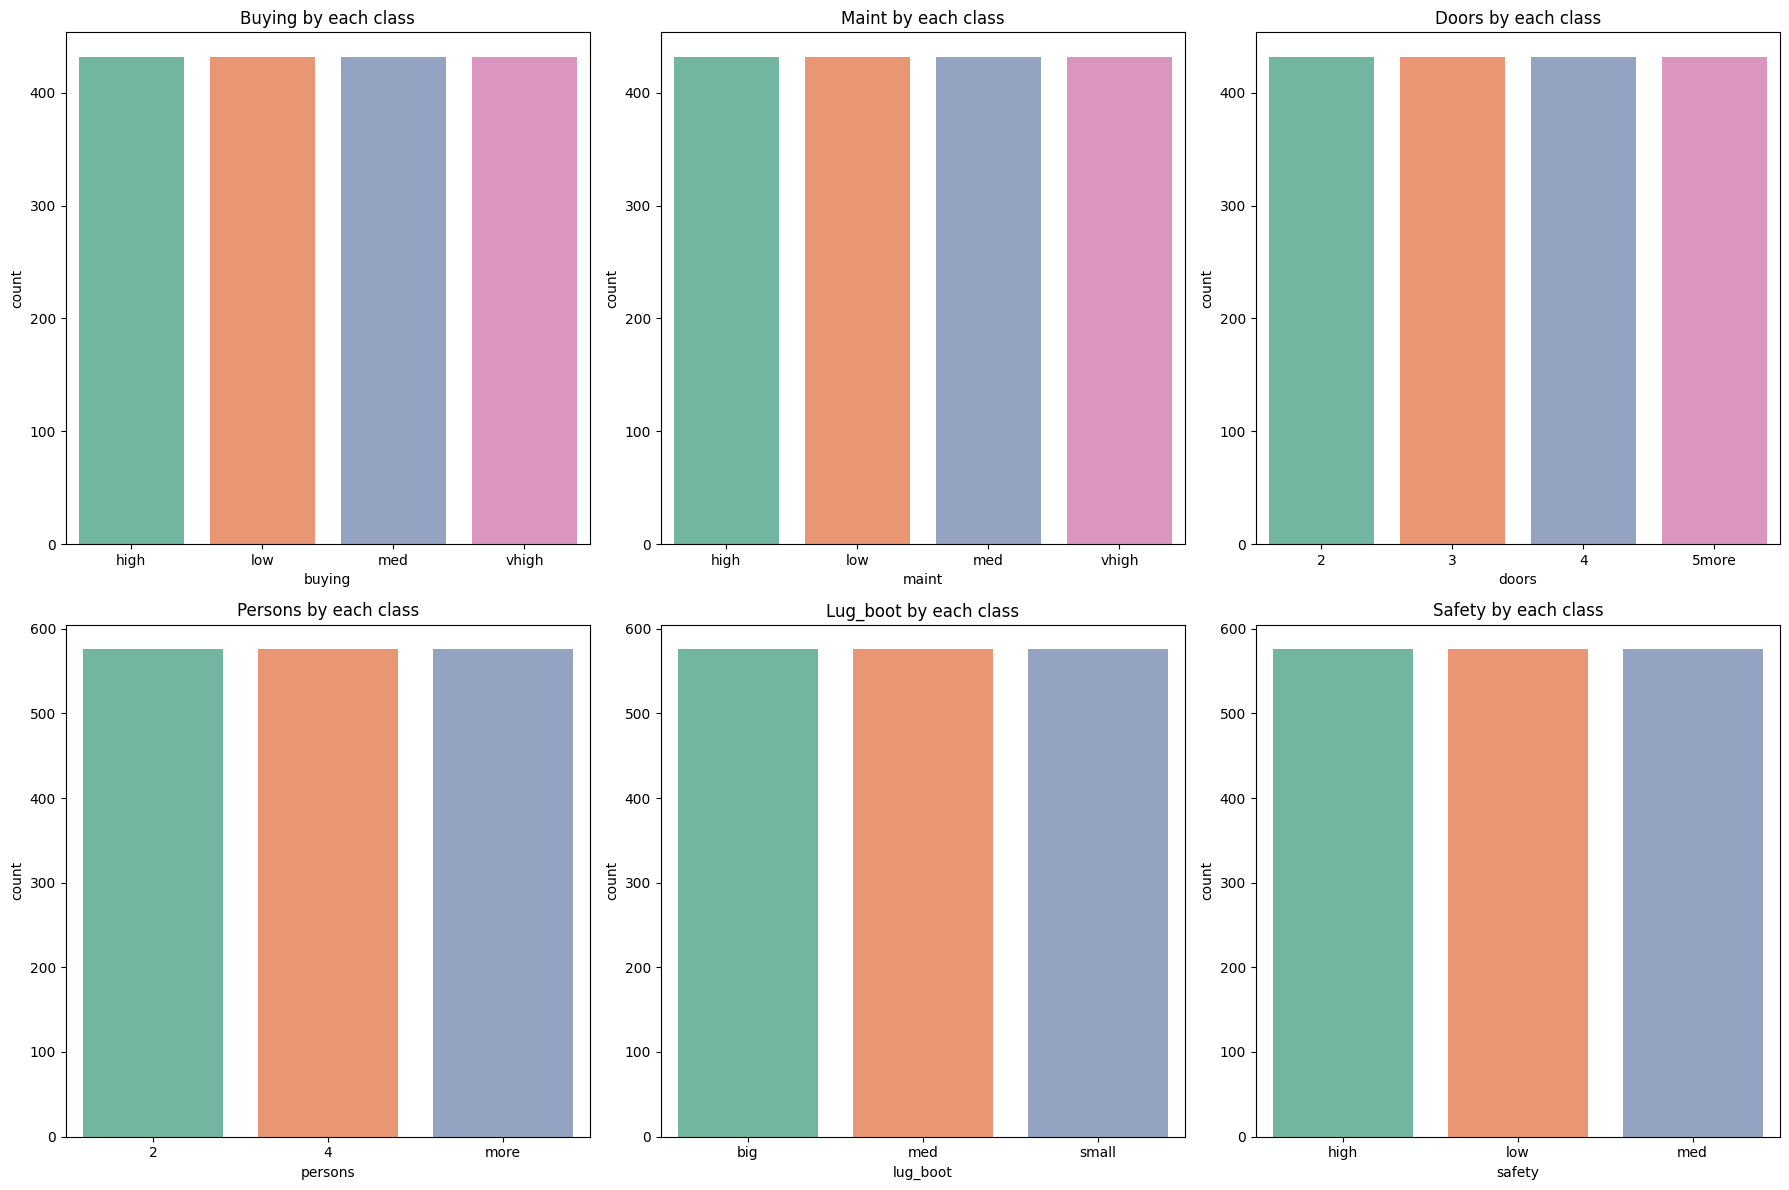

In [8]:
features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, feature in enumerate(features):
    row, col = divmod(i, 3)
    sns.countplot(x=feature, data=car_evaluation_df, ax=axes[row, col], hue=feature, palette='Set2')
    axes[row, col].set_title(f'{feature.capitalize()} by each class')

plt.tight_layout()
plt.show()

In [22]:
import prince

# Perform Multiple Correspondence Analysis (MCA)
mca = prince.MCA(
    n_components=2,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# Fit MCA on the car evaluation dataset
mca = mca.fit(car_evaluation_df)

# Transform the data
mca_transformed = mca.transform(car_evaluation_df)

# Display the principal coordinates of the rows
print(mca_transformed.head())

          0         1
0 -0.981183  0.039888
1 -0.698137 -0.188483
2 -0.570899 -0.052124
3 -0.888481  0.062876
4 -0.605435 -0.165496


In [21]:
mca.plot(car_evaluation_df, show_column_labels=True, show_row_labels=False)

alt.LayerChart(...)